In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/final/base_dataset.csv")
df_engagement = pd.read_csv("../data/final/engagement_features.csv")
df_reviews_feat = pd.read_csv("../data/final/review_features.csv")
df_support = pd.read_csv("../data/final/support_features.csv")
df_money = pd.read_csv("../data/final/money_features.csv")

In [3]:
print(df.shape)
print(df_engagement.shape)
print(df_reviews_feat.shape)
print(df_support.shape)
print(df_money.shape)

(480, 13)
(480, 16)
(480, 15)
(480, 16)
(480, 15)


In [6]:
df = df_engagement.merge(
    df_reviews_feat[["app_id", "positive_percent", "review_score_bucket"]],
    on="app_id",
    how="left"
)

df = model_df.merge(
    df_support[["app_id", "days_since_update", "recent_update", "has_patchnotes"]],
    on="app_id",
    how="left"
)

df = model_df.merge(
    df_money[["app_id", "is_paid", "price_bucket"]],
    on="app_id",
    how="left"
)

df.head()

,app_id,name,release_date,is_free,price_usd,dlc_count,total_reviews,total_positive,total_negative,positive_ratio,...,log_players,positive_percent,review_score_bucket,days_since_update,recent_update,has_patchnotes,is_paid_x,price_bucket_x,is_paid_y,price_bucket_y
0,10,Counter-Strike,2000-11-01,0,9.99,0,34614.0,33453.0,1161.0,0.966459,...,9.480215,0.966459,excellent,874.0,False,True,-1,free,-1,free
1,20,Team Fortress Classic,NaN,0,7.50,0,4192.0,3617.0,575.0,0.862834,...,3.891820,0.862834,excellent,579.0,False,True,-1,free,-1,free
2,30,Day of Defeat,2003-05-01,0,4.99,0,2142.0,1902.0,240.0,0.887955,...,4.499810,0.887955,excellent,2400.0,False,True,-1,cheap,-1,cheap
3,40,Deathmatch Classic,2001-06-01,0,4.99,0,1262.0,1043.0,219.0,0.826466,...,1.609438,0.826466,good,2400.0,False,True,-1,cheap,-1,cheap
4,50,Half-Life: Opposing Force,1999-11-01,0,4.99,0,13104.0,12496.0,608.0,0.953602,...,4.700480,0.953602,excellent,2400.0,False,True,-1,cheap,-1,cheap


In [7]:
df.to_csv("../data/final/modeling_dataset.csv", index=False)

print("Modeling dataset saved.")

Modeling dataset saved.


In [10]:
model_df = df.copy()
print(df.shape)
model_df = model_df.replace([np.inf, -np.inf], np.nan)

model_df = model_df.dropna(subset=[
    "current_players",
    "total_reviews",
    "positive_ratio",
    "game_age_days",
    "days_since_update"
])

model_df.shape

(480, 25)


(332, 25)

In [12]:
features = [
    "total_reviews",
    "positive_ratio",
    "game_age_days",
    "days_since_update"
]

X = model_df[features]
y = model_df["log_players"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R² Score: 0.5154629363476166
MAE: 1.4512563869309072


In [13]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": reg_model.coef_
})

coef_df.sort_values("coefficient", ascending=False)

,feature,coefficient
1,positive_ratio,2.259727
0,total_reviews,0.000012
2,game_age_days,-0.000105
3,days_since_update,-0.001204


In [14]:
threshold = model_df["current_players"].quantile(0.75)

model_df["high_staying_power"] = (
    model_df["current_players"] >= threshold
).astype(int)

print("Threshold:", threshold)
print(model_df["high_staying_power"].value_counts())

Threshold: 4423.0
high_staying_power
0    249
1     83
Name: count, dtype: int64


In [17]:
features = [
    "total_reviews",
    "positive_ratio",
    "game_age_days",
    "days_since_update"
]

X = model_df[features]
y = model_df["high_staying_power"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9104477611940298
[[49  1]
 [ 5 12]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        50
           1       0.92      0.71      0.80        17

    accuracy                           0.91        67
   macro avg       0.92      0.84      0.87        67
weighted avg       0.91      0.91      0.91        67



In [20]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8507462686567164
[[45  5]
 [ 5 12]]
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        50
           1       0.71      0.71      0.71        17

    accuracy                           0.85        67
   macro avg       0.80      0.80      0.80        67
weighted avg       0.85      0.85      0.85        67



In [21]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)
importance_df

,feature,importance
0,total_reviews,0.337680
3,days_since_update,0.319139
2,game_age_days,0.203868
1,positive_ratio,0.139313


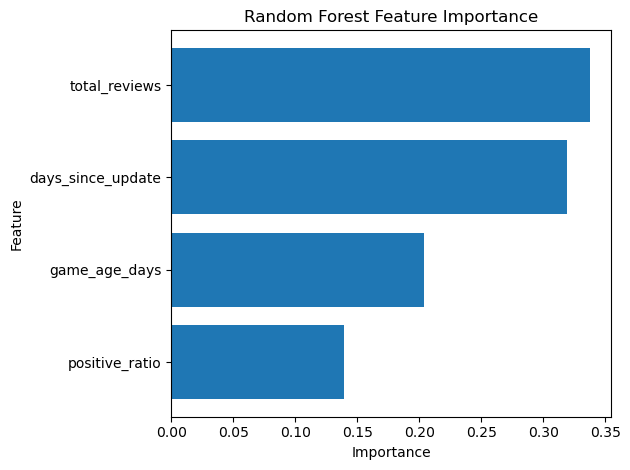

In [22]:
importance_plot = importance_df.sort_values("importance", ascending=True)

plt.barh(importance_plot["feature"], importance_plot["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()